# Full-Dataset Clean Federated Learning on DNN-EdgeIIoT

This is the full-data continuation of the approved
`02_simple_clean_federated_pipeline.ipynb` trial.

It keeps the same binary target, contamination exclusions, capture grouping,
conflicting-pattern removal, exact-feature deduplication, training-only
preprocessing, five IID clients, and Flower FedAvg workflow. The two deliberate
changes are:

1. **No 10% balanced sample:** every row that survives the approved cleaning is
   used, with the clean dataset's natural class prevalence.
2. **No centralized DNN:** training starts directly with the federated model to
   reduce runtime, as requested.

Because the raw CSV contains many conflicting or feature-identical packet rows,
"full dataset" here means **all clean unique rows after the approved controls**.
The notebook reports raw, excluded, and modeled row counts so that scope is
explicit.

## 1. Imports, configuration, and hardware policy

This run writes only to `artifacts_full/` and `results_full/`; it cannot
overwrite notebook 02's outputs. CSV loading is restricted to the approved 25
model features plus target/grouping metadata, which materially reduces peak
RAM. Federated clients run sequentially. A CUDA GPU is used only when at least
1 GiB is free; otherwise the run falls back to CPU with a bounded thread count.

In [1]:
import copy, gc, json, os, random, shutil, sys, time, warnings
from collections import OrderedDict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from torch.utils.data import DataLoader, Subset, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

HERE = Path.cwd().resolve()
if (HERE / "notebooks" / "03_full_dataset_federated_pipeline.ipynb").exists():
    PROJECT_ROOT = HERE
elif HERE.name == "notebooks" and (HERE / "03_full_dataset_federated_pipeline.ipynb").exists():
    PROJECT_ROOT = HERE.parent
else:
    raise RuntimeError("Run this notebook from the experiment root or its notebooks directory.")

REPO_ROOT = next(
    (p for p in (PROJECT_ROOT, *PROJECT_ROOT.parents) if (p / "data").is_dir()),
    PROJECT_ROOT,
)
DATA_PATH = Path(
    os.environ.get(
        "EDGEIIOT_DATASET",
        REPO_ROOT / "data" / "raw" / "DNN-EdgeIIoT-dataset.csv",
    )
)
ARTIFACTS = PROJECT_ROOT / "artifacts_full"
RESULTS = PROJECT_ROOT / "results_full"
ARTIFACTS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

CONFIG = {
    "seed": 42,
    "train_fraction": 0.70,
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "batch_size": 512,
    "hidden_layers": [128, 64, 32],
    "dropout": [0.20, 0.10],
    "learning_rate": 0.001,
    "local_epochs": 2,
    "federated_rounds": 10,
    "num_clients": 5,
    "client_names": ["Factory_A", "Factory_B", "Factory_C", "Factory_D", "Factory_E"],
    "threshold": 0.5,
    "max_group_rows": 10_000,
    "leakage_flag_accuracy": 0.995,
    "cpu_threads": max(1, min(4, (os.cpu_count() or 2) - 1)),
    "prefer_cuda": True,
    "minimum_free_cuda_gb": 1.0,
}
assert abs(
    CONFIG["train_fraction"] + CONFIG["val_fraction"] + CONFIG["test_fraction"] - 1.0
) < 1e-12

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
torch.set_num_threads(CONFIG["cpu_threads"])

cuda_free_gb = None
if torch.cuda.is_available():
    try:
        free_bytes, _ = torch.cuda.mem_get_info()
        cuda_free_gb = free_bytes / 1024**3
    except RuntimeError:
        cuda_free_gb = 0.0
use_cuda = bool(
    CONFIG["prefer_cuda"]
    and torch.cuda.is_available()
    and cuda_free_gb is not None
    and cuda_free_gb >= CONFIG["minimum_free_cuda_gb"]
)
FED_DEVICE = torch.device("cuda" if use_cuda else "cpu")
PIN_MEMORY = FED_DEVICE.type == "cuda"

disk = shutil.disk_usage(PROJECT_ROOT)
hardware = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "logical_cpus": os.cpu_count(),
    "torch_cpu_threads": CONFIG["cpu_threads"],
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_free_gb_at_start": None if cuda_free_gb is None else round(cuda_free_gb, 3),
    "federated_device": str(FED_DEVICE),
    "project_disk_free_gb": round(disk.free / 1024**3, 2),
}
print(json.dumps(hardware, indent=2))
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Dataset:", DATA_PATH)
print("Outputs:", ARTIFACTS, "and", RESULTS)

{
  "python": "3.11.0",
  "pytorch": "2.5.1+cu121",
  "logical_cpus": 16,
  "torch_cpu_threads": 4,
  "cuda_available": true,
  "cuda_free_gb_at_start": 5.033,
  "federated_device": "cuda",
  "project_disk_free_gb": 40.0
}
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Dataset: <local dataset path>
Outputs: C:\Projects\ids-fl-project\ids-fl-project\experiments\edgeiiot_federated\artifacts_full and C:\Projects\ids-fl-project\ids-fl-project\experiments\edgeiiot_federated\results_full


## 2. Approved schema and memory-conscious CSV load

The feature manifest is frozen to the 25 fields approved in notebook 02. All
other source columns are accounted for by that notebook's exclusion report.
The schema assertion stops the run if the CSV changes, rather than silently
using an unreviewed field. `usecols` avoids loading payloads, identities, and
other excluded columns into RAM.

In [2]:
APPROVED_FEATURES = [
    "arp.opcode", "arp.hw.size", "http.content_length", "http.response",
    "tcp.connection.fin", "tcp.connection.rst", "tcp.connection.syn",
    "tcp.connection.synack", "tcp.flags", "tcp.flags.ack", "tcp.len",
    "udp.time_delta", "dns.qry.name", "dns.qry.qu", "dns.retransmission",
    "dns.retransmit_request", "mqtt.conflag.cleansess", "mqtt.conflags",
    "mqtt.hdrflags", "mqtt.len", "mqtt.msgtype", "mqtt.proto_len",
    "mqtt.topic_len", "mqtt.ver", "mbtcp.len",
]

APPROVED_DROP_REASONS = {
    "Attack_type": "attack name; grouping only",
    "frame.time": "capture timestamp; grouping only",
    "ip.src_host": "source host identity",
    "ip.dst_host": "destination host identity",
    "arp.src.proto_ipv4": "host identity",
    "arp.dst.proto_ipv4": "host identity",
    "tcp.srcport": "capture/source port identity",
    "tcp.dstport": "capture/target port identity",
    "udp.port": "capture port identity",
    "icmp.transmit_timestamp": "capture timestamp",
    "tcp.payload": "raw payload",
    "mqtt.msg": "raw message",
    "http.file_data": "payload/body",
    "http.request.full_uri": "URL/payload content",
    "http.request.uri.query": "query/payload content",
    "http.referer": "raw HTTP text",
    "http.request.method": "protocol text/source-format shortcut",
    "http.request.version": "confirmed attack-content/schema pollution",
    "mqtt.conack.flags": "confirmed source-format leakage",
    "mqtt.protoname": "confirmed source-format leakage",
    "mqtt.topic": "confirmed source-format leakage",
    "dns.qry.name.len": "confirmed source-format/schema pollution",
    "tcp.options": "raw protocol text/high-cardinality identifier",
    "tcp.checksum": "packet checksum/capture-specific",
    "icmp.checksum": "packet checksum/capture-specific",
    "tcp.seq": "absolute sequence identifier",
    "tcp.ack": "absolute acknowledgement identifier",
    "tcp.ack_raw": "absolute acknowledgement identifier",
    "icmp.seq_le": "packet sequence identifier",
    "udp.stream": "capture stream identifier",
    "mbtcp.trans_id": "transaction identifier",
    "mbtcp.unit_id": "device/unit identity",
    "dns.retransmit_request_in": "capture frame reference",
    "dns.qry.type": "constant or entirely missing",
    "http.tls_port": "constant or entirely missing",
    "icmp.unused": "constant or entirely missing",
    "mqtt.msg_decoded_as": "constant or entirely missing",
}

assert DATA_PATH.exists(), DATA_PATH
header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
required = APPROVED_FEATURES + ["Attack_label", "Attack_type", "frame.time"]
missing = sorted(set(required) - set(header))
unaccounted = sorted(
    set(header) - set(APPROVED_FEATURES) - {"Attack_label"} - set(APPROVED_DROP_REASONS)
)
assert not missing, f"Required approved columns missing: {missing}"
assert not unaccounted, f"Unreviewed source columns found: {unaccounted}"

t0 = time.time()
raw = pd.read_csv(DATA_PATH, usecols=required, low_memory=False, memory_map=True)
load_seconds = time.time() - t0
assert set(raw["Attack_label"].dropna().unique()) == {0, 1}
raw_rows = int(len(raw))
raw_counts = raw["Attack_label"].value_counts().sort_index()
loaded_memory_mb = float(raw.memory_usage(index=True, deep=True).sum() / 1024**2)
print(f"Loaded {raw_rows:,} rows x {raw.shape[1]} selected columns in {load_seconds:.1f}s")
print(f"Selected-column DataFrame memory: {loaded_memory_mb:,.1f} MiB")
print(pd.DataFrame({
    "class": ["Normal", "Attack"],
    "rows": [int(raw_counts.get(0, 0)), int(raw_counts.get(1, 0))],
    "fraction": [float(raw_counts.get(0, 0) / raw_rows), float(raw_counts.get(1, 0) / raw_rows)],
}).to_string(index=False))

Loaded 2,219,201 rows x 28 selected columns in 32.8s
Selected-column DataFrame memory: 540.6 MiB
 class    rows  fraction
Normal 1615643  0.728029
Attack  603558  0.271971


## 3. Capture groups and semantic normalization

As in notebook 02, capture groups are constructed **before** attack names and
timestamps are removed. A group combines attack/capture block, five-minute
window, and bounded contiguous chunk. Approved model fields are then normalized
to numeric values; infinity is treated as missing. Grouping fields are dropped
immediately afterwards to lower memory pressure.

In [3]:
def make_capture_groups(df, max_group_rows):
    parts = df["frame.time"].astype("string").str.extract(
        r"(\d{2}):(\d{2}):(\d{2})", expand=True
    )
    seconds = (
        pd.to_numeric(parts[0], errors="coerce") * 3600
        + pd.to_numeric(parts[1], errors="coerce") * 60
        + pd.to_numeric(parts[2], errors="coerce")
    )
    delta = seconds - seconds.shift()
    new_run = (
        df["Attack_type"].ne(df["Attack_type"].shift())
        | (seconds.notna() & seconds.shift().notna() & (delta < -300))
    )
    run_id = new_run.cumsum()
    time_window = (seconds // 300).fillna(-1).astype("int64")
    base = (
        df["Attack_type"].astype("string")
        + "|run=" + run_id.astype("string")
        + "|window=" + time_window.astype("string")
    )
    chunk = base.groupby(base, sort=False).cumcount() // max_group_rows
    return (base + "|chunk=" + chunk.astype("string")).astype("category")

t0 = time.time()
raw["_capture_group"] = make_capture_groups(raw, CONFIG["max_group_rows"])
assert raw.groupby("_capture_group", observed=True)["Attack_label"].nunique().max() == 1
group_count_before_cleaning = int(raw["_capture_group"].nunique())

MISSING_TOKENS = {"", "na", "n/a", "nan", "none", "null", "?", "inf", "+inf", "-inf"}
converted_rows = []
for col in APPROVED_FEATURES:
    if not pd.api.types.is_numeric_dtype(raw[col]):
        s = raw[col].astype("string").str.strip()
        s = s.mask(s.str.lower().isin(MISSING_TOKENS))
        zero = (
            s.str.match(r"^[+-]?0+(?:\.0+)?$", na=False)
            | s.str.match(r"(?i)^0x0+$", na=False)
        )
        s = s.mask(zero, "0")
        numeric = pd.to_numeric(s, errors="coerce")
        nonmissing = int(s.notna().sum())
        ratio = float(numeric.notna().sum() / nonmissing) if nonmissing else 0.0
        assert ratio >= 0.98, f"Approved feature is no longer mostly numeric: {col} ({ratio:.3f})"
        raw[col] = numeric
        converted_rows.append({
            "column": col,
            "numeric_fraction": round(ratio, 4),
            "nonmissing_values": nonmissing,
        })
    raw[col] = raw[col].replace([np.inf, -np.inf], np.nan)

raw.drop(columns=["Attack_type", "frame.time"], inplace=True)
normalization_seconds = time.time() - t0
converted_numeric = pd.DataFrame(converted_rows)
print(f"Constructed {group_count_before_cleaning:,} pure-label groups and normalized features "
      f"in {normalization_seconds:.1f}s")
display(converted_numeric if len(converted_numeric) else pd.DataFrame({"result": ["all approved features already numeric"]}))
print(f"Working DataFrame memory after early column removal: "
      f"{raw.memory_usage(index=True, deep=True).sum()/1024**2:,.1f} MiB")

Constructed 547 pure-label groups and normalized features in 19.6s


,result
0,all approved features already numeric


Working DataFrame memory after early column removal: 444.5 MiB


## 4. Approved conflict removal and exact-feature deduplication

The same final-representation controls as notebook 02 are applied globally:

- remove every feature pattern observed with both binary labels;
- among remaining same-label duplicates, retain one representative row.

These are cleaning exclusions, not sampling. No clean unique row is discarded
after this step. The accounting table is important: it states exactly how the
2.2M-packet source maps to the full modeling population.

In [4]:
assert all(pd.api.types.is_numeric_dtype(raw[c]) for c in APPROVED_FEATURES)
feature_hash = pd.util.hash_pandas_object(raw[APPROVED_FEATURES], index=False)
label_span = (
    pd.DataFrame({"hash": feature_hash, "label": raw["Attack_label"]})
    .groupby("hash")["label"]
    .agg(["min", "max"])
)
ambiguous_hashes = label_span.index[label_span["min"] != label_span["max"]]
ambiguous_mask = feature_hash.isin(ambiguous_hashes)
ambiguous_rows = int(ambiguous_mask.sum())

nonambiguous = raw.loc[
    ~ambiguous_mask, APPROVED_FEATURES + ["Attack_label", "_capture_group"]
].copy()
duplicate_mask = nonambiguous.duplicated(subset=APPROVED_FEATURES, keep="first")
duplicate_rows = int(duplicate_mask.sum())
clean = nonambiguous.loc[~duplicate_mask].reset_index(drop=True)

assert len(clean) + ambiguous_rows + duplicate_rows == raw_rows
assert not clean.duplicated(subset=APPROVED_FEATURES).any()
assert clean.groupby("_capture_group", observed=True)["Attack_label"].nunique().max() == 1

clean_rows = int(len(clean))
clean_counts = clean["Attack_label"].value_counts().sort_index()
scope_accounting = pd.DataFrame([
    {"stage": "Raw CSV rows", "rows": raw_rows, "share_of_raw": 1.0},
    {"stage": "Removed: conflicting-label feature patterns", "rows": ambiguous_rows,
     "share_of_raw": ambiguous_rows / raw_rows},
    {"stage": "Removed: same-label exact-feature duplicates", "rows": duplicate_rows,
     "share_of_raw": duplicate_rows / raw_rows},
    {"stage": "Full clean unique modeling population", "rows": clean_rows,
     "share_of_raw": clean_rows / raw_rows},
])
display(scope_accounting.style.format({"rows": "{:,.0f}", "share_of_raw": "{:.3%}"}))
print("Full clean class distribution:")
display(pd.DataFrame({
    "class": ["Normal", "Attack"],
    "rows": [int(clean_counts.get(0, 0)), int(clean_counts.get(1, 0))],
    "fraction": [float(clean_counts.get(0, 0) / clean_rows),
                 float(clean_counts.get(1, 0) / clean_rows)],
}).style.format({"rows": "{:,.0f}", "fraction": "{:.3%}"}))

del raw, nonambiguous, feature_hash, label_span, ambiguous_mask
gc.collect()
print(f"All {clean_rows:,} clean unique rows continue to modeling; sampling_fraction = 1.0.")

,stage,rows,share_of_raw
0,Raw CSV rows,"2,219,201",100.000%
1,Removed: conflicting-label feature patterns,"1,628,811",73.396%
2,Removed: same-label exact-feature duplicates,"574,563",25.891%
3,Full clean unique modeling population,"15,827",0.713%


Full clean class distribution:


,class,rows,fraction
0,Normal,"3,199",20.212%
1,Attack,"12,628",79.788%


All 15,827 clean unique rows continue to modeling; sampling_fraction = 1.0.


## 5. Row-aware, group-disjoint train/validation/test split

Notebook 02 stratified by the **number of groups**. At full scale, unequal group
sizes can make row counts and class prevalence differ sharply across splits.
Here groups remain strictly disjoint, but a deterministic greedy allocator works
within each class and targets 70/15/15 of its rows. This preserves natural
prevalence as closely as the indivisible capture groups allow.

No split is resampled or balanced. Warnings are reported if any split differs
from the full clean attack rate by more than five percentage points.

,groups,rows,row_fraction,normal,attack,attack_fraction,attack_rate_delta
split,,,,,,,
train,39,"11,079",70.001%,"2,239","8,840",79.791%,+0.003%
validation,32,"2,374",15.000%,480,"1,894",79.781%,-0.007%
test,31,"2,374",15.000%,480,"1,894",79.781%,-0.007%


Distribution warnings: none
Confirmed: every clean row is assigned once; group overlap = 0; exact-feature overlap = 0.


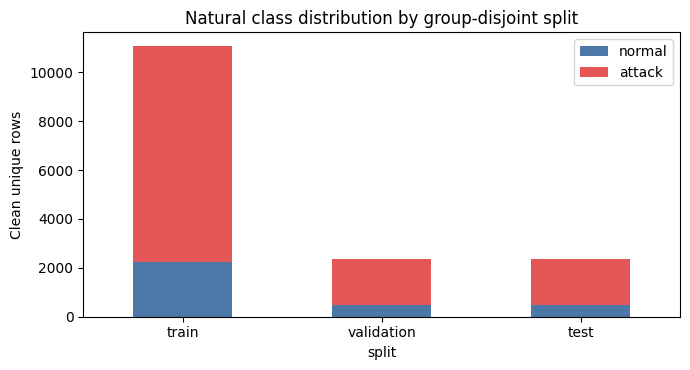

In [5]:
group_table = (
    clean.groupby("_capture_group", observed=True)
    .agg(label=("Attack_label", "first"), rows=("Attack_label", "size"))
)
assert group_table.groupby("label").size().min() >= 3

SPLIT_FRACTIONS = {
    "train": CONFIG["train_fraction"],
    "validation": CONFIG["val_fraction"],
    "test": CONFIG["test_fraction"],
}

def row_aware_group_assignment(table, fractions, seed):
    rng = np.random.default_rng(seed)
    names = list(fractions)
    assignment = {}
    for label, subset in table.groupby("label"):
        work = subset.reset_index().copy()
        work["_tie_break"] = rng.random(len(work))
        work = work.sort_values(["rows", "_tie_break"], ascending=[False, True])
        target = {name: float(work["rows"].sum() * fractions[name]) for name in names}
        assigned_rows = {name: 0 for name in names}
        for _, row in work.iterrows():
            chosen = min(
                names,
                key=lambda name: (
                    sum(
                        (
                            assigned_rows[candidate]
                            + (int(row["rows"]) if candidate == name else 0)
                            - target[candidate]
                        ) ** 2
                        for candidate in names
                    ),
                    names.index(name),
                ),
            )
            assignment[row["_capture_group"]] = chosen
            assigned_rows[chosen] += int(row["rows"])
    return assignment

group_assignment = row_aware_group_assignment(
    group_table, SPLIT_FRACTIONS, CONFIG["seed"]
)
clean["_split"] = clean["_capture_group"].map(group_assignment).astype("string")
assert clean["_split"].notna().all()

splits = {
    name: clean.loc[clean["_split"] == name].reset_index(drop=True)
    for name in ["train", "validation", "test"]
}
assert sum(len(frame) for frame in splits.values()) == clean_rows
group_sets = {
    name: set(frame["_capture_group"].astype("string"))
    for name, frame in splits.items()
}
assert group_sets["train"].isdisjoint(group_sets["validation"])
assert group_sets["train"].isdisjoint(group_sets["test"])
assert group_sets["validation"].isdisjoint(group_sets["test"])

split_hashes = {
    name: set(pd.util.hash_pandas_object(frame[APPROVED_FEATURES], index=False).tolist())
    for name, frame in splits.items()
}
assert split_hashes["train"].isdisjoint(split_hashes["validation"])
assert split_hashes["train"].isdisjoint(split_hashes["test"])
assert split_hashes["validation"].isdisjoint(split_hashes["test"])

overall_attack_rate = float(clean["Attack_label"].mean())
split_distribution = pd.DataFrame([
    {
        "split": name,
        "groups": frame["_capture_group"].nunique(),
        "rows": len(frame),
        "row_fraction": len(frame) / clean_rows,
        "normal": int((frame["Attack_label"] == 0).sum()),
        "attack": int((frame["Attack_label"] == 1).sum()),
        "attack_fraction": float(frame["Attack_label"].mean()),
        "attack_rate_delta": float(frame["Attack_label"].mean() - overall_attack_rate),
    }
    for name, frame in splits.items()
]).set_index("split")
display(split_distribution.style.format({
    "rows": "{:,.0f}",
    "row_fraction": "{:.3%}",
    "normal": "{:,.0f}",
    "attack": "{:,.0f}",
    "attack_fraction": "{:.3%}",
    "attack_rate_delta": "{:+.3%}",
}))

distribution_warnings = []
for name, row in split_distribution.iterrows():
    if abs(row["attack_rate_delta"]) > 0.05:
        distribution_warnings.append(
            f"{name} attack prevalence differs from full clean data by "
            f"{row['attack_rate_delta']:+.1%}"
        )
    if abs(row["row_fraction"] - SPLIT_FRACTIONS[name]) > 0.10:
        distribution_warnings.append(
            f"{name} row share differs from target by "
            f"{row['row_fraction'] - SPLIT_FRACTIONS[name]:+.1%}"
        )
print("Distribution warnings:", distribution_warnings if distribution_warnings else "none")
print("Confirmed: every clean row is assigned once; group overlap = 0; exact-feature overlap = 0.")

ax = split_distribution[["normal", "attack"]].plot.bar(
    stacked=True, figsize=(7, 3.8), color=["#4C78A8", "#E45756"]
)
ax.set_ylabel("Clean unique rows")
ax.set_title("Natural class distribution by group-disjoint split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Training-only leakage audit and preprocessing

The one-feature decision-stump audit is fitted only on training rows. Median
imputation and standardization are also fitted only on training data, then
applied unchanged to validation and test. The untouched test set is not used
for feature review, model selection, threshold selection, or checkpointing.

In [6]:
train_df, val_df, test_df = splits["train"], splits["validation"], splits["test"]
X_train_raw = train_df[APPROVED_FEATURES].copy()
y_train = train_df["Attack_label"].to_numpy(np.float32)
X_val_raw = val_df[APPROVED_FEATURES].copy()
y_val = val_df["Attack_label"].to_numpy(np.float32)
X_test_raw = test_df[APPROVED_FEATURES].copy()
y_test = test_df["Attack_label"].to_numpy(np.float32)

audit_rows = []
min_leaf = max(50, int(round(0.01 * len(X_train_raw))))
for col in APPROVED_FEATURES:
    x = X_train_raw[[col]].replace([np.inf, -np.inf], np.nan)
    fill = x[col].median()
    stump = DecisionTreeClassifier(
        max_depth=1, min_samples_leaf=min_leaf, random_state=CONFIG["seed"]
    )
    stump.fit(x.fillna(fill), y_train.astype(int))
    accuracy = float(stump.score(x.fillna(fill), y_train.astype(int)))
    audit_rows.append({
        "feature": col,
        "training_stump_accuracy": accuracy,
        "flagged": accuracy >= CONFIG["leakage_flag_accuracy"],
    })
leakage_audit = (
    pd.DataFrame(audit_rows)
    .sort_values("training_stump_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(leakage_audit.head(10).round(4))
flagged = leakage_audit.loc[leakage_audit["flagged"], "feature"].tolist()
print("Near-perfect training-only flags:", flagged if flagged else "none")

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
for name, array in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    assert array.dtype == np.float32
    assert np.isfinite(array).all(), f"NaN/Inf in {name}"
assert preprocessor.n_features_in_ == len(APPROVED_FEATURES)

dropped_report = (
    pd.DataFrame(
        [{"column": col, "reason": reason} for col, reason in APPROVED_DROP_REASONS.items()]
    )
    .sort_values("column")
    .reset_index(drop=True)
)
joblib.dump(preprocessor, ARTIFACTS / "preprocessor.joblib")
(ARTIFACTS / "feature_list.json").write_text(
    json.dumps(APPROVED_FEATURES, indent=2), encoding="utf-8"
)
dropped_report.to_csv(ARTIFACTS / "dropped_columns.csv", index=False)
leakage_audit.to_csv(RESULTS / "training_feature_audit.csv", index=False)
split_distribution.reset_index().to_csv(RESULTS / "split_distributions.csv", index=False)

print("Processed shapes:", X_train.shape, X_val.shape, X_test.shape)
print(f"Processed arrays occupy "
      f"{(X_train.nbytes + X_val.nbytes + X_test.nbytes)/1024**2:.2f} MiB total.")
print("Confirmed: preprocessor fitted on training rows only.")

,feature,training_stump_accuracy,flagged
0,udp.time_delta,0.9498,False
1,dns.retransmission,0.9473,False
2,dns.qry.qu,0.9411,False
3,dns.qry.name,0.9276,False
4,tcp.len,0.8201,False
5,arp.hw.size,0.7979,False
6,http.content_length,0.7979,False
7,http.response,0.7979,False
8,arp.opcode,0.7979,False
9,tcp.flags,0.7979,False


Near-perfect training-only flags: none
Processed shapes: (11079, 25) (2374, 25) (2374, 25)
Processed arrays occupy 1.51 MiB total.
Confirmed: preprocessor fitted on training rows only.


## 7. Shared MLP, imbalance-aware objective, and metrics

There is deliberately no centralized training section. All clients use the same
MLP architecture. The full clean population is attack-majority, so a single
training-derived `pos_weight = Normal / Attack` balances class contributions to
the binary cross-entropy loss. This is equivalent to down-weighting the majority
Attack label; it does **not** resample or alter validation/test prevalence.

Checkpoint selection uses **validation macro-F1**, which gives Normal and Attack
equal importance. Final reporting includes accuracy, balanced accuracy,
attack-F1, macro-F1, MCC, false-alarm rate, and missed-attack rate.

In [7]:
class BinaryMLP(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=(0.20, 0.10)):
        super().__init__()
        layers, previous = [], input_dim
        for i, width in enumerate(hidden):
            layers += [nn.Linear(previous, width), nn.ReLU()]
            if i < len(dropout):
                layers.append(nn.Dropout(dropout[i]))
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def loader_for(X, y, shuffle, indices=None):
    dataset = TensorDataset(
        torch.from_numpy(np.asarray(X, np.float32)),
        torch.from_numpy(np.asarray(y, np.float32)).view(-1, 1),
    )
    if indices is not None:
        dataset = Subset(dataset, np.asarray(indices, dtype=np.int64).tolist())
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=0,
        pin_memory=PIN_MEMORY,
    )

normal_train = int((y_train == 0).sum())
attack_train = int((y_train == 1).sum())
POS_WEIGHT_VALUE = float(normal_train / attack_train)

def criterion_for(device):
    return nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([POS_WEIGHT_VALUE], dtype=torch.float32, device=device)
    )

def metric_bundle(y, probability, loss=None):
    y = np.asarray(y).astype(int)
    probability = np.asarray(probability)
    pred = (probability >= CONFIG["threshold"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    metrics = {
        "accuracy": float((pred == y).mean()),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "macro_f1": float(f1_score(y, pred, average="macro", zero_division=0)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "roc_auc": float(roc_auc_score(y, probability)),
        "pr_auc": float(average_precision_score(y, probability)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "normal_support": int(tn + fp), "attack_support": int(fn + tp),
        "fpr": float(fp / (fp + tn)) if fp + tn else 0.0,
        "fnr": float(fn / (fn + tp)) if fn + tp else 0.0,
    }
    if loss is not None:
        metrics["loss"] = float(loss)
    return metrics

@torch.no_grad()
def evaluate_array(model, X, y, device):
    model.to(device).eval()
    criterion = criterion_for(device)
    probabilities, total_loss, seen = [], 0.0, 0
    for xb, yb in loader_for(X, y, False):
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)
        logits = model(xb)
        loss = criterion(logits, yb)
        probabilities.append(torch.sigmoid(logits).cpu().numpy().ravel())
        total_loss += loss.item() * len(xb)
        seen += len(xb)
    return metric_bundle(y, np.concatenate(probabilities), total_loss / seen)

model_preview = BinaryMLP(
    X_train.shape[1], CONFIG["hidden_layers"], CONFIG["dropout"]
)
print(model_preview)
print("Trainable parameters:", f"{sum(p.numel() for p in model_preview.parameters()):,}")
print(f"Training class counts: Normal={normal_train:,}, Attack={attack_train:,}")
print(f"BCE pos_weight (Normal/Attack): {POS_WEIGHT_VALUE:.5f}")
print("Model-selection metric: validation macro-F1")

BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 13,697
Training class counts: Normal=2,239, Attack=8,840
BCE pos_weight (Normal/Attack): 0.25328
Model-selection metric: validation macro-F1


## 8. Five natural-prevalence IID client partitions

Only training rows are partitioned. Each class is shuffled and divided across
five clients, so client shards are disjoint, similarly sized, and closely match
the **natural training prevalence** rather than being forced to 50/50. Clients
reference shared arrays by index; five persistent copies are not kept in RAM.

,client,rows,normal,attack,attack_fraction,attack_rate_delta,batches_per_local_epoch
0,Factory_A,"2,216",448,"1,768",79.783%,-0.007%,5
1,Factory_B,"2,216",448,"1,768",79.783%,-0.007%,5
2,Factory_C,"2,216",448,"1,768",79.783%,-0.007%,5
3,Factory_D,"2,216",448,"1,768",79.783%,-0.007%,5
4,Factory_E,"2,215",447,"1,768",79.819%,+0.029%,5


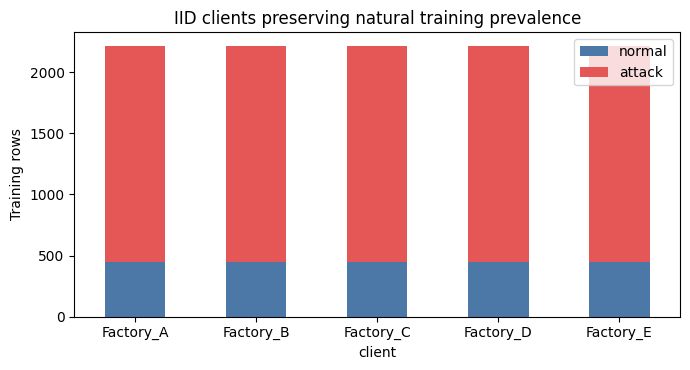

Confirmed: five disjoint clients, all training rows used once, one shared architecture.


In [8]:
rng = np.random.default_rng(CONFIG["seed"])
partitions = {name: [] for name in CONFIG["client_names"]}
for label in [0, 1]:
    indices = np.where(y_train.astype(int) == label)[0]
    rng.shuffle(indices)
    for name, chunk in zip(
        CONFIG["client_names"], np.array_split(indices, CONFIG["num_clients"])
    ):
        partitions[name].append(chunk)

for name in partitions:
    partitions[name] = np.concatenate(partitions[name])
    rng.shuffle(partitions[name])

all_client_indices = np.concatenate(list(partitions.values()))
assert len(partitions) == CONFIG["num_clients"]
assert len(np.unique(all_client_indices)) == len(all_client_indices) == len(X_train)
train_attack_rate = float(y_train.mean())
client_rows = []
architecture_signatures = []
for name, indices in partitions.items():
    labels = y_train[indices].astype(int)
    architecture_signatures.append(str(BinaryMLP(
        X_train.shape[1], CONFIG["hidden_layers"], CONFIG["dropout"]
    )))
    client_rows.append({
        "client": name,
        "rows": len(indices),
        "normal": int((labels == 0).sum()),
        "attack": int((labels == 1).sum()),
        "attack_fraction": float(labels.mean()),
        "attack_rate_delta": float(labels.mean() - train_attack_rate),
        "batches_per_local_epoch": int(np.ceil(len(indices) / CONFIG["batch_size"])),
    })
assert len(set(architecture_signatures)) == 1

client_distribution = pd.DataFrame(client_rows)
client_distribution.to_csv(RESULTS / "client_distributions.csv", index=False)
display(client_distribution.style.format({
    "rows": "{:,.0f}",
    "normal": "{:,.0f}",
    "attack": "{:,.0f}",
    "attack_fraction": "{:.3%}",
    "attack_rate_delta": "{:+.3%}",
}))
assert client_distribution["attack_rate_delta"].abs().max() < 0.01

ax = client_distribution.set_index("client")[["normal", "attack"]].plot.bar(
    stacked=True, figsize=(7, 3.8), color=["#4C78A8", "#E45756"]
)
ax.set_ylabel("Training rows")
ax.set_title("IID clients preserving natural training prevalence")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Confirmed: five disjoint clients, all training rows used once, one shared architecture.")

## 9. Sequential Flower FedAvg training

Flower's Message/Record `FedAvg` strategy aggregates every client update,
weighted by the client's number of examples. Clients train one at a time, so
only one local model occupies the selected device. Round 0 is the seeded random
initialization. After every round the server evaluates on the central
validation split and saves the best validation macro-F1 checkpoint.

This remains a simulation: central preprocessing and a central validation set
are explicit conveniences, not privacy-preserving federated preprocessing.

Reference: https://flower.ai/docs/framework/ref-api/flwr.serverapp.strategy.FedAvg.html

Flower: 1.32.1
Federated execution: sequential in-process clients on cuda


INFO :      aggregate_train: Received 5 results and 0 failures


Round 01/10: 6.2s, val macro-F1=0.8671
First-round projection: about 1.0 min total if later rounds are similar.


INFO :      aggregate_train: Received 5 results and 0 failures


Round 02/10: 1.0s, val macro-F1=0.8659


...

INFO :      aggregate_train: Received 5 results and 0 failures


Round 09/10: 0.6s, val macro-F1=0.9062


INFO :      aggregate_train: Received 5 results and 0 failures


Round 10/10: 0.8s, val macro-F1=0.9088
Federated wall time: 13.5s | best round: 10 | best validation macro-F1: 0.90882


,round,validation_loss,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_macro_f1,validation_fpr,validation_fnr
0,0,0.28106,0.23294,0.50061,0.09628,0.21499,0.05000,0.94879
1,1,0.25875,0.89975,0.93717,0.93296,0.86715,0.00000,0.12566
2,2,0.22040,0.89890,0.93509,0.93243,0.86588,0.00417,0.12566
3,3,0.16372,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
4,4,0.11280,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
5,5,0.08361,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
6,6,0.07472,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
7,7,0.06685,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
8,8,0.06675,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025
9,9,0.06691,0.93302,0.95258,0.95635,0.90623,0.01458,0.08025


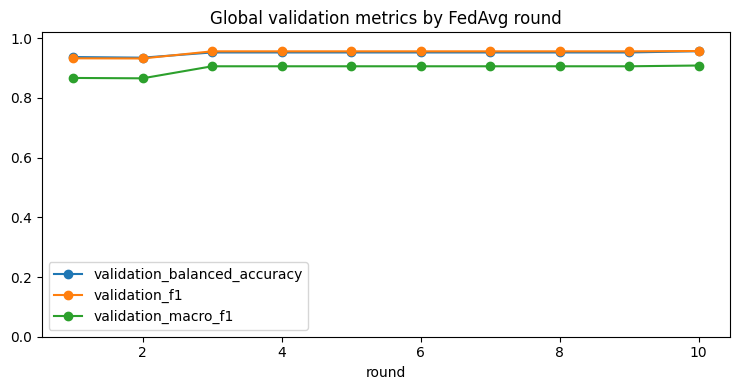

In [9]:
import flwr as fl
from flwr.app import ArrayRecord, Message, MetricRecord, RecordDict
from flwr.serverapp.strategy import FedAvg

print("Flower:", fl.__version__)
print("Federated execution: sequential in-process clients on", FED_DEVICE)

def get_parameters(model):
    return [value.detach().cpu().numpy() for value in model.state_dict().values()]

def set_parameters(model, parameters):
    state = OrderedDict(
        (key, torch.tensor(value))
        for key, value in zip(model.state_dict().keys(), parameters)
    )
    model.load_state_dict(state, strict=True)

strategy = FedAvg(
    fraction_train=1.0,
    fraction_evaluate=0.0,
    min_train_nodes=CONFIG["num_clients"],
    min_evaluate_nodes=0,
    min_available_nodes=CONFIG["num_clients"],
    weighted_by_key="num-examples",
)
fed_records = {
    "rounds": [],
    "clients": [],
    "best_macro_f1": -1.0,
    "best_round": -1,
}
FED_MODEL_PATH = ARTIFACTS / "federated_global_model.pt"

def evaluate_global(server_round, parameters):
    model = BinaryMLP(
        X_val.shape[1], CONFIG["hidden_layers"], CONFIG["dropout"]
    )
    set_parameters(model, parameters)
    metrics = evaluate_array(model, X_val, y_val, FED_DEVICE)
    fed_records["rounds"].append({
        "round": server_round,
        "validation_loss": metrics["loss"],
        "validation_accuracy": metrics["accuracy"],
        "validation_balanced_accuracy": metrics["balanced_accuracy"],
        "validation_f1": metrics["f1"],
        "validation_macro_f1": metrics["macro_f1"],
        "validation_fpr": metrics["fpr"],
        "validation_fnr": metrics["fnr"],
    })
    if server_round > 0 and metrics["macro_f1"] > fed_records["best_macro_f1"] + 1e-8:
        fed_records["best_macro_f1"] = metrics["macro_f1"]
        fed_records["best_round"] = server_round
        torch.save({
            "state_dict": model.state_dict(),
            "input_dim": X_val.shape[1],
            "hidden_layers": CONFIG["hidden_layers"],
            "dropout": CONFIG["dropout"],
            "round": server_round,
            "validation_metrics": metrics,
            "pos_weight": POS_WEIGHT_VALUE,
        }, FED_MODEL_PATH)
    del model
    if FED_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

set_seed(CONFIG["seed"])
initial_model = BinaryMLP(
    X_train.shape[1], CONFIG["hidden_layers"], CONFIG["dropout"]
)
global_parameters = get_parameters(initial_model)
del initial_model
evaluate_global(0, global_parameters)

federated_start = time.time()
for server_round in range(1, CONFIG["federated_rounds"] + 1):
    round_start = time.time()
    replies = []
    for client_id, name in enumerate(CONFIG["client_names"]):
        indices = partitions[name]
        local_model = BinaryMLP(
            X_train.shape[1], CONFIG["hidden_layers"], CONFIG["dropout"]
        ).to(FED_DEVICE)
        set_parameters(local_model, global_parameters)
        torch.manual_seed(CONFIG["seed"] + client_id * 100 + server_round)
        optimizer = torch.optim.Adam(
            local_model.parameters(), lr=CONFIG["learning_rate"]
        )
        criterion = criterion_for(FED_DEVICE)
        train_loader = loader_for(X_train, y_train, True, indices=indices)
        local_model.train()
        loss_sum, seen = 0.0, 0
        for _ in range(CONFIG["local_epochs"]):
            for xb, yb in train_loader:
                xb = xb.to(FED_DEVICE, non_blocking=PIN_MEMORY)
                yb = yb.to(FED_DEVICE, non_blocking=PIN_MEMORY)
                optimizer.zero_grad(set_to_none=True)
                loss = criterion(local_model(xb), yb)
                loss.backward()
                optimizer.step()
                loss_sum += loss.item() * len(xb)
                seen += len(xb)
        mean_train_loss = loss_sum / seen
        fed_records["clients"].append({
            "round": server_round,
            "client": name,
            "num_examples": len(indices),
            "mean_train_loss": mean_train_loss,
        })
        content = RecordDict({
            "arrays": ArrayRecord(numpy_ndarrays=get_parameters(local_model)),
            "metrics": MetricRecord({
                "num-examples": len(indices),
                "train-loss": mean_train_loss,
            }),
        })
        replies.append(
            Message(dst_node_id=0, message_type="train", content=content)
        )
        del local_model, optimizer, criterion, train_loader
        if FED_DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    aggregated, _ = strategy.aggregate_train(server_round, replies)
    assert aggregated is not None, "Flower did not return an aggregated model"
    global_parameters = aggregated.to_numpy_ndarrays()
    evaluate_global(server_round, global_parameters)
    round_seconds = time.time() - round_start
    print(
        f"Round {server_round:02d}/{CONFIG['federated_rounds']}: "
        f"{round_seconds:.1f}s, "
        f"val macro-F1={fed_records['rounds'][-1]['validation_macro_f1']:.4f}"
    )
    if server_round == 1:
        print(
            f"First-round projection: about "
            f"{round_seconds * CONFIG['federated_rounds'] / 60:.1f} min total "
            f"if later rounds are similar."
        )

federated_wall_seconds = time.time() - federated_start
assert FED_MODEL_PATH.exists() and fed_records["best_round"] > 0
round_metrics = pd.DataFrame(fed_records["rounds"]).sort_values("round").reset_index(drop=True)
client_metrics = pd.DataFrame(fed_records["clients"])
round_metrics.to_csv(RESULTS / "federated_round_metrics.csv", index=False)
client_metrics.to_csv(RESULTS / "client_round_metrics.csv", index=False)

print(
    f"Federated wall time: {federated_wall_seconds:.1f}s | "
    f"best round: {fed_records['best_round']} | "
    f"best validation macro-F1: {fed_records['best_macro_f1']:.5f}"
)
display(round_metrics.round(5))
ax = round_metrics[round_metrics["round"] > 0].plot(
    x="round",
    y=["validation_balanced_accuracy", "validation_f1", "validation_macro_f1"],
    marker="o",
    ylim=(0, 1.02),
    figsize=(7.5, 4),
)
ax.set_title("Global validation metrics by FedAvg round")
plt.tight_layout()
plt.show()

## 10. One-time evaluation of the best global model

The checkpoint chosen solely by validation macro-F1 is evaluated once on the
untouched, naturally distributed, group-disjoint test set. Accuracy is shown
alongside prevalence-robust metrics and both operational error rates.

,federated_test
accuracy,0.97810
balanced_accuracy,0.97383
precision,0.99146
recall,0.98099
f1,0.98620
macro_f1,0.96657
mcc,0.93345
roc_auc,0.99698
pr_auc,0.99867
fpr,0.03333


,support,recall,error_rate
class,,,
Normal,480,96.667%,3.333%
Attack,"1,894",98.099%,1.901%


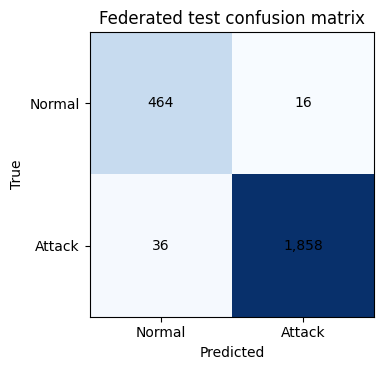

Test rows: 2,374 | attack prevalence: 79.781%
Best checkpoint round: 10
Confirmed: test data was used once, after checkpoint selection.


In [10]:
TEST_TOUCHED_FOR_FITTING = False
assert not TEST_TOUCHED_FOR_FITTING

checkpoint = torch.load(FED_MODEL_PATH, map_location="cpu", weights_only=True)
federated_model = BinaryMLP(
    checkpoint["input_dim"], checkpoint["hidden_layers"], checkpoint["dropout"]
)
federated_model.load_state_dict(checkpoint["state_dict"])
federated_test = evaluate_array(
    federated_model, X_test, y_test, FED_DEVICE
)
federated_output = {
    "best_round": int(checkpoint["round"]),
    "selection_metric": "validation_macro_f1",
    **federated_test,
}
(RESULTS / "federated_final_metrics.json").write_text(
    json.dumps(federated_output, indent=2), encoding="utf-8"
)

reported_metrics = [
    "accuracy", "balanced_accuracy", "precision", "recall", "f1", "macro_f1",
    "mcc", "roc_auc", "pr_auc", "fpr", "fnr",
]
display(
    pd.Series({key: federated_test[key] for key in reported_metrics})
    .to_frame("federated_test")
    .round(5)
)

cm = np.array([
    [federated_test["tn"], federated_test["fp"]],
    [federated_test["fn"], federated_test["tp"]],
])
per_class = pd.DataFrame([
    {
        "class": "Normal",
        "support": federated_test["normal_support"],
        "recall": 1.0 - federated_test["fpr"],
        "error_rate": federated_test["fpr"],
    },
    {
        "class": "Attack",
        "support": federated_test["attack_support"],
        "recall": federated_test["recall"],
        "error_rate": federated_test["fnr"],
    },
]).set_index("class")
display(per_class.style.format({"support": "{:,.0f}", "recall": "{:.3%}", "error_rate": "{:.3%}"}))

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(cm, cmap="Blues")
ax.set(
    xticks=[0, 1], yticks=[0, 1],
    xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"],
    xlabel="Predicted", ylabel="True",
    title="Federated test confusion matrix",
)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")
plt.tight_layout()
plt.show()

print("Test rows:", f"{len(y_test):,}", "| attack prevalence:", f"{y_test.mean():.3%}")
print("Best checkpoint round:", checkpoint["round"])
print("Confirmed: test data was used once, after checkpoint selection.")

## 11. Save scope, distribution, hardware, and run summary

The summary records enough context to distinguish this full natural-prevalence
run from the balanced trial: row accounting, split/client distributions,
hardware choice, configuration, timing, checkpoint rule, and final metrics.

In [11]:
run_summary = {
    "notebook": "03_full_dataset_federated_pipeline.ipynb",
    "dataset_scope": "all clean unique rows after approved conflict and duplicate controls",
    "sampling_fraction_after_cleaning": 1.0,
    "class_balancing_or_resampling": False,
    "centralized_dnn_run": False,
    "raw_rows": raw_rows,
    "raw_class_counts": {
        "normal": int(raw_counts.get(0, 0)),
        "attack": int(raw_counts.get(1, 0)),
    },
    "ambiguous_conflicting_rows_removed": ambiguous_rows,
    "same_label_duplicate_rows_removed": duplicate_rows,
    "clean_unique_rows": clean_rows,
    "clean_class_counts": {
        "normal": int(clean_counts.get(0, 0)),
        "attack": int(clean_counts.get(1, 0)),
    },
    "final_feature_count": len(APPROVED_FEATURES),
    "grouping_method": (
        "Attack_type capture block + time-reset run + 5-minute window "
        "+ bounded contiguous chunk"
    ),
    "split_method": "class-stratified row-aware greedy assignment of indivisible capture groups",
    "group_overlap": 0,
    "exact_feature_overlap": 0,
    "split_distributions": split_distribution.reset_index().to_dict(orient="records"),
    "distribution_warnings": distribution_warnings,
    "client_distributions": client_distribution.to_dict(orient="records"),
    "client_partition": "five row-level IID shards preserving natural training prevalence",
    "loss": {
        "name": "BCEWithLogitsLoss",
        "pos_weight_normal_over_attack": POS_WEIGHT_VALUE,
    },
    "selection_metric": "validation_macro_f1",
    "best_round": int(checkpoint["round"]),
    "federated_wall_seconds": federated_wall_seconds,
    "csv_load_seconds": load_seconds,
    "normalization_and_grouping_seconds": normalization_seconds,
    "hardware": hardware,
    "config": CONFIG,
    "federated_test": federated_test,
}
(RESULTS / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2), encoding="utf-8"
)

print(f"Raw rows: {raw_rows:,}")
print(f"Full clean unique rows used: {clean_rows:,} (100% after approved cleaning)")
print("Centralized DNN run: no")
print("Group overlap: 0 | exact-feature overlap: 0")
print(
    f"Federated test: accuracy={federated_test['accuracy']:.4f}, "
    f"balanced_accuracy={federated_test['balanced_accuracy']:.4f}, "
    f"macro_F1={federated_test['macro_f1']:.4f}, "
    f"FPR={federated_test['fpr']:.4f}, FNR={federated_test['fnr']:.4f}"
)
print("Saved full-data artifacts to:", ARTIFACTS)
print("Saved full-data results to:", RESULTS)

Raw rows: 2,219,201
Full clean unique rows used: 15,827 (100% after approved cleaning)
Centralized DNN run: no
Group overlap: 0 | exact-feature overlap: 0
Federated test: accuracy=0.9781, balanced_accuracy=0.9738, macro_F1=0.9666, FPR=0.0333, FNR=0.0190
Saved full-data artifacts to: C:\Projects\ids-fl-project\ids-fl-project\experiments\edgeiiot_federated\artifacts_full
Saved full-data results to: C:\Projects\ids-fl-project\ids-fl-project\experiments\edgeiiot_federated\results_full


## 12. Interpretation and limitations

**What this notebook establishes**

- The entire approved clean unique population is used; there is no post-cleaning
  sample and no 50/50 rebalance.
- Capture groups and exact feature patterns are disjoint across
  train/validation/test.
- Natural prevalence is carried through the split and IID clients, with
  explicit shift diagnostics.
- The only trained DNN is the federated global model.
- Sequential clients, restricted CSV columns, shared arrays, bounded CPU
  threads, and guarded single-GPU use limit hardware pressure.

**Limitations that remain**

- The removal of conflicting and duplicate feature patterns is inherited from
  the approved trial. Consequently, "full" is 100% of the *clean unique*
  population, not all 2.2M raw packet rows. The scope table must accompany any
  reported result.
- Clients are IID row partitions from one laboratory dataset, not real
  heterogeneous factories. This run tests scale and natural class imbalance,
  not non-IID generalization.
- The row-aware split keeps capture groups intact but cannot guarantee exact
  70/15/15 counts because groups are indivisible.
- Class-weighted BCE improves attention to the minority Normal class but can
  change probability calibration. The fixed 0.5 threshold was not tuned on the
  test set.
- Central preprocessing, server validation, and local sequential execution are
  simulation conveniences. There is no secure aggregation, differential
  privacy, or real network deployment.
- This remains one seeded run. Repeated seeds and a group-definition
  sensitivity analysis are required for uncertainty claims.